# DeepRacer trace analysis

End-to-end analysis of a dr-gym training run, driven entirely through the
**new deepracer-utils API** that understands the dr-gym Tier-1 trace
(`deepracer.logs.gym_trace`), plus **MLflow / TensorBoard / Optuna**.

What this shows:

1. **Load the trace as a first-class deepracer-utils object** — `GymTraceLog`
   reads the Parquet shards and derives the classic columns, so the original
   `AnalysisUtils` / `SimtraceStabilityAnalyzer` run on it unchanged.
2. **Track path** — the car's route on the track outline (`plot_last_eval_path`).
3. **rliable** — reliable RL evaluation (IQM + CIs, performance profiles,
   sample-efficiency) across the Optuna trials (`deepracer.logs.rliable_utils`).
4. **MLflow / TensorBoard / Optuna** cross-checks.

Run with the project's `analysis` group:

```
uv run --group analysis jupyter lab notebooks/trace_analysis.ipynb
```


In [1]:
import os, sys, glob
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "optuna.db").exists() or (cand / "artifacts").is_dir():
            return cand
    return p

PROJECT = find_project_root()
sys.path.insert(0, str(PROJECT))  # so `import gym_dr` works from notebooks/

# deepracer-utils is installed from GitHub via the `analysis` dep group
# (`uv sync --group analysis`). Fall back to a local source checkout for dev.
DU_SRC = next((p for p in [PROJECT.parent / "deepracer-utils",
                           Path("/home/lunav0/Projects/deepracer-utils")] if p.exists()), None)
try:
    import deepracer.logs  # installed
except ModuleNotFoundError:
    if DU_SRC:
        sys.path.insert(0, str(DU_SRC))
    import deepracer.logs  # noqa: F401
import deepracer
print("deepracer-utils:", deepracer.__file__)

# Track .npy waypoints aren't shipped in the wheel; point at a local checkout's
# bundled tracks when available (else set DEEPRACER_TRACKS_DIR yourself).
if DU_SRC and not os.environ.get("DEEPRACER_TRACKS_DIR"):
    td = DU_SRC / "tests" / "deepracer" / "track_utils" / "tracks"
    if td.is_dir():
        os.environ["DEEPRACER_TRACKS_DIR"] = str(td)

RUNS = [r for r in sorted(PROJECT.glob("artifacts/trace_smoke_trial_*")) if list(r.glob("trace/steps/ep_*.parquet"))]
print("project:", PROJECT, "| runs:", [r.name for r in RUNS])


deepracer-utils: /home/lunav0/Projects/dr-gym/.venv/lib/python3.8/site-packages/deepracer/__init__.py
project: /home/lunav0/Projects/dr-gym | runs: ['trace_smoke_trial_3', 'trace_smoke_trial_4', 'trace_smoke_trial_5']


## 1. Load the trace via `GymTraceLog`

`GymTraceLog(run).load()` reads the Parquet shards and derives the classic internal columns (`tstamp`, `iteration`, `unique_episode`, …). No adapter, no S3, no folder contract — the gym trace is now a first-class citizen.

In [2]:
from deepracer.logs import GymTraceLog, load_gym_traces

log = GymTraceLog(str(RUNS[-1])).load()
df = log.dataframe()
print("rows:", len(df), "| episodes:", df["unique_episode"].nunique(), "| world:", df["world_name"].dropna().unique().tolist())
print("phase tags:", df["phase"].value_counts().to_dict())
df[["unique_episode","steps","world_name","x","y","speed","progress","on_track","reward","episode_status","phase"]].head(3)


rows: 7386 | episodes: 16 | world: ['reinvent_base']
phase tags: {'train': 7386}


,unique_episode,steps,world_name,x,y,speed,progress,on_track,reward,episode_status,phase
0,0,1,reinvent_base,3.200123,0.683099,0.100000,0.792754,True,0.019819,in_progress,train
1,0,2,reinvent_base,3.203767,0.682931,0.255708,0.813328,True,0.051994,in_progress,train
2,0,3,reinvent_base,3.215953,0.683402,0.100000,0.882145,True,0.022054,in_progress,train


## 2. Original deepracer-utils analysis, unchanged

`SimtraceStabilityAnalyzer` (step-timing) and `AnalysisUtils.simulation_agg` (per-episode aggregates) run directly on the loaded gym trace.

In [3]:
from deepracer.logs import AnalysisUtils

display(log.stability.analyze())

agg = AnalysisUtils.simulation_agg(df.copy(), firstgroup="iteration", secondgroup="episode", add_tstamp=True)
display(agg[["episode","steps","progress","speed","reward","time","complete"]].tail(8))


,worker,iteration,count,avg_ms,max_ms,p95_ms,std_ms,rtf,train_time_s,policy_time_s,ratio
0,0,0,7370,118.572323,19331.582069,77.664316,585.669752,1.0,902.6212,None,None


new reward not found, using reward as its values


,episode,steps,progress,speed,reward,time,complete
8,8,329,49.760883,0.448636,-382.987924,37.220225,0
9,9,1289,76.407755,0.121260,-2101.684565,123.481812,0
10,10,919,51.496898,0.116516,-1559.865913,71.902718,0
11,11,442,72.456203,0.467605,-128.158586,49.921975,0
12,12,327,48.300714,0.451227,-288.010328,41.696271,0
13,13,306,49.370813,0.563308,-0.026721,41.814582,0
14,14,349,85.135539,0.518845,-6.280562,52.507428,0
15,15,264,48.300714,0.575304,-220.103268,50.020122,0


## 3. Track path — where did the car drive?

`plot_last_eval_path` draws the car's route on the track outline, coloured by speed. It uses the **last evaluation episode** when the trace has `phase=='eval'` rows; otherwise it falls back to the best-progress episode. `load_track` pulls the bundled `reinvent_base` waypoints (point `DEEPRACER_TRACKS_DIR` at a folder of `<world>.npy` for other tracks).

Loaded 119 waypoints


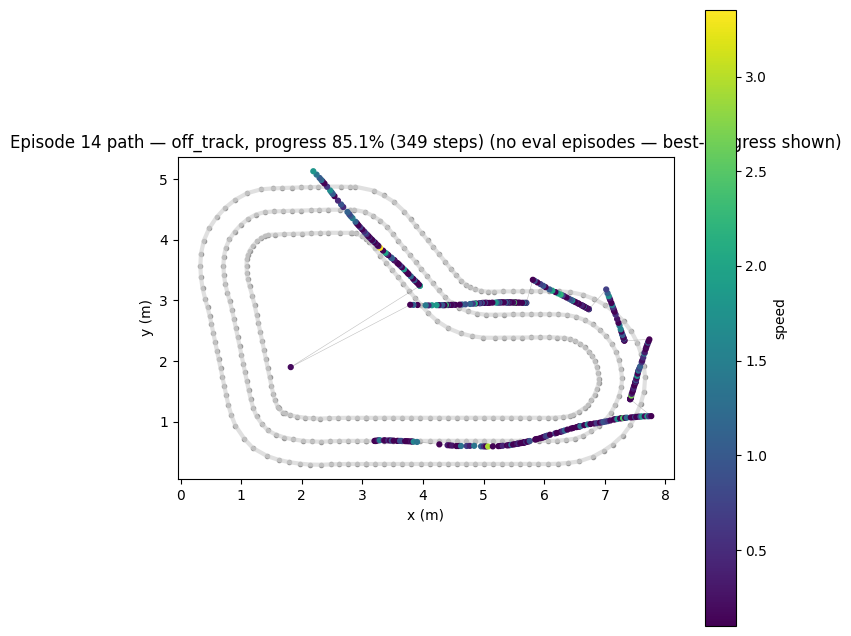

In [4]:
from deepracer.logs import load_track, plot_last_eval_path, plot_episode_path

track = load_track(df["world_name"].dropna().iloc[0])
plot_last_eval_path(df, track, value_field="speed")
plt.show()


## 4. rliable — reliable RL evaluation across trials

Point estimates of the mean hide RL's run-to-run variance. `rliable` reports **IQM** (robust aggregate) and friends with bootstrap CIs, performance profiles, and sample-efficiency curves. Here each Optuna **trial is a run**; the score is per-episode `progress` (normalised to [0,1]).

score matrix (runs x episodes): (3, 16)


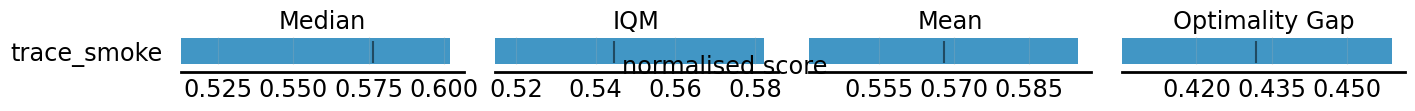

In [5]:
from deepracer.logs import (score_dict, plot_aggregate_metrics,
                            plot_performance_profile, plot_sample_efficiency)

# phase=None: this run predates the per-episode eval tagging; use all episodes.
sd = score_dict({"trace_smoke": [str(r) for r in RUNS]}, metric="progress", phase=None)
print("score matrix (runs x episodes):", sd["trace_smoke"].shape)

plot_aggregate_metrics(sd, reps=2000); plt.show()


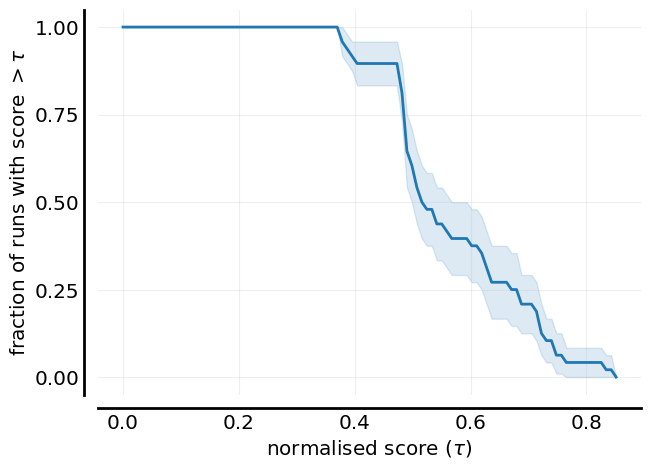

In [6]:
plot_performance_profile(sd, reps=500); plt.show()

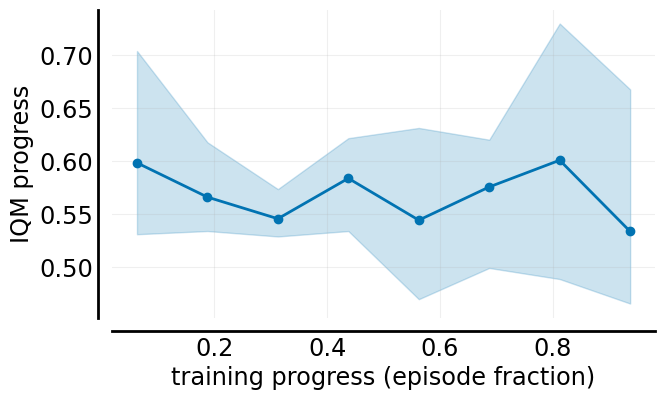

In [7]:
plot_sample_efficiency([str(r) for r in RUNS], metric="progress", phase=None, n_bins=8, reps=500); plt.show()

## 5. MLflow run metrics

,tags.mlflow.runName,status,metrics.dr/ep_reward,metrics.dr/ep_max_progress,metrics.eval/mean_reward,params.trainer.kwargs.learning_rate
0,trace_smoke_trial_5,FINISHED,-6.280562,85.135539,3958.953314,0.00012854415975274456
1,trace_smoke_trial_4,FINISHED,-45.126706,37.249184,3016.626474,0.0003248192869770287
2,trace_smoke_trial_3,FINISHED,239.064497,50.265657,3228.899918,0.00018272261776066238


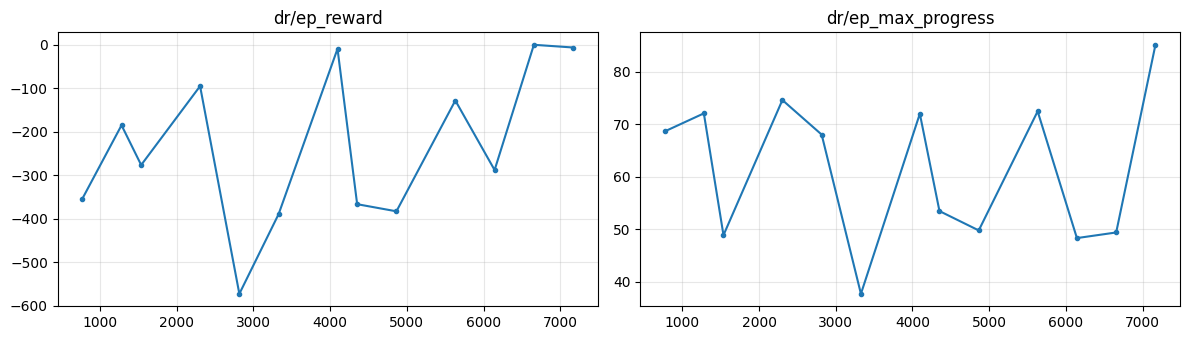

In [8]:
import mlflow
from mlflow.tracking import MlflowClient
mlflow.set_tracking_uri(f"file:{PROJECT / 'mlruns'}")
exp = mlflow.get_experiment_by_name("trace-smoke")
if exp is None:
    print("no 'trace-smoke' experiment")
else:
    runs = mlflow.search_runs([exp.experiment_id])
    keep = [c for c in ["tags.mlflow.runName","status","metrics.dr/ep_reward",
                        "metrics.dr/ep_max_progress","metrics.eval/mean_reward",
                        "params.trainer.kwargs.learning_rate"] if c in runs.columns]
    display(runs[keep])
    rid = runs.sort_values("start_time")["run_id"].iloc[-1]
    client = MlflowClient()
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
    for key, a in zip(["dr/ep_reward","dr/ep_max_progress"], ax):
        h = client.get_metric_history(rid, key)
        if h: a.plot([x.step for x in h], [x.value for x in h], marker="."); a.set_title(key); a.grid(alpha=.3)
    plt.tight_layout(); plt.show()


## 6. TensorBoard scalars

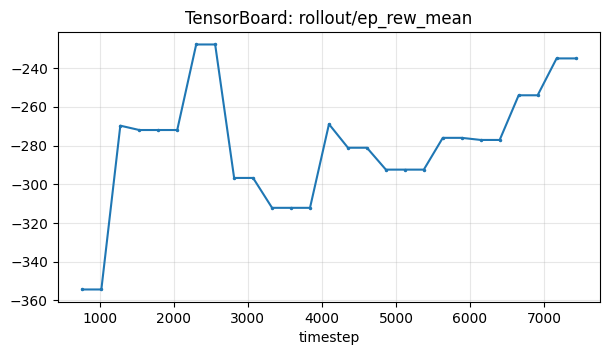

In [9]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
ev = sorted(PROJECT.glob("artifacts/*/tensorboard/**/events.out.tfevents.*"))
if ev:
    ea = EventAccumulator(str(ev[-1].parent)); ea.Reload()
    tags = ea.Tags().get("scalars", [])
    want = next((t for t in ["rollout/ep_rew_mean","train/value_loss"] if t in tags), tags[0] if tags else None)
    if want:
        s = ea.Scalars(want)
        plt.figure(figsize=(7,3.5)); plt.plot([e.step for e in s],[e.value for e in s], marker=".", ms=3)
        plt.title(f"TensorBoard: {want}"); plt.xlabel("timestep"); plt.grid(alpha=.3); plt.show()
else:
    print("no TensorBoard events")


## 7. Optuna study

/home/lunav0/Projects/dr-gym/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,number,value,params_ent_coef,params_learning_rate,state
0,0,NaN,0.041232,0.000183,FAIL
1,1,NaN,0.010402,0.000325,FAIL
2,2,NaN,0.001841,0.000129,FAIL
3,3,3228.899918,0.041232,0.000183,COMPLETE
4,4,3016.626474,0.010402,0.000325,COMPLETE
5,5,3958.953314,0.001841,0.000129,COMPLETE


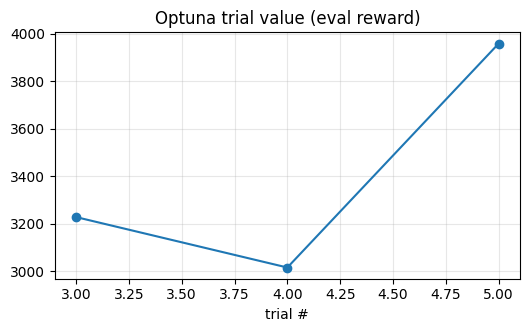

In [10]:
import optuna
try:
    study = optuna.load_study(study_name="trace_smoke", storage=f"sqlite:///{PROJECT/'optuna.db'}")
    tdf = study.trials_dataframe()
    display(tdf[[c for c in tdf.columns if c in ('number','value','state') or c.startswith('params_')]])
    done = [t for t in study.trials if t.value is not None]
    if done:
        plt.figure(figsize=(6,3.2)); plt.plot([t.number for t in done],[t.value for t in done], marker="o")
        plt.title("Optuna trial value (eval reward)"); plt.xlabel("trial #"); plt.grid(alpha=.3); plt.show()
except Exception as e:
    print("optuna unavailable:", repr(e))
